In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from skimage.measure import label, regionprops
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

DATA_DIR = Path('../archive')
plt.rcParams['figure.dpi'] = 120

In [2]:
def segmentar_grao(caminho):
    bgr = cv2.imread(caminho)
    if bgr is None:
        raise FileNotFoundError(f"Imagem não encontrada: {caminho}")
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_open)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
    if num_labels <= 1:
        mask = closed
    else:
        areas = stats[1:, cv2.CC_STAT_AREA]
        max_idx = np.argmax(areas) + 1
        mask = np.zeros_like(closed, dtype=np.uint8)
        mask[labels == max_idx] = 255
    return bgr, gray, mask

In [3]:
import os
import random

target_por_classe = {
    "Full Black": 50
}

TARGET_DEFAULT = 55

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

for classe in os.listdir(DATA_DIR):

    class_folder = os.path.join(DATA_DIR, classe)

    if not os.path.isdir(class_folder):
        continue

    # pega target específico ou padrão
    target = target_por_classe.get(classe, TARGET_DEFAULT)

    imagens = [
        img for img in os.listdir(class_folder)
        if img.lower().endswith(valid_extensions)
    ]

    total = len(imagens)

    if total == target:
        print(f"{classe}: " f"{total} (ok)")
        continue

    if total < target:
        print(f"{classe}: " f"{total} (< {target}) " f"(mantida)"
        )
        continue

    manter = set(random.sample(imagens,target))

    removidas = 0

    for img in imagens:
        if img not in manter:
            os.remove(os.path.join(class_folder,img))
            removidas += 1

    print(f"{classe}: "f"{total} → {target} "f"(removidas {removidas})")

print("\nBalanceamento concluído!")

Broken: 55 (ok)
Full Black: 50 (ok)
Full Sour: 55 (ok)
Immature: 55 (ok)
Partial Black: 55 (ok)
Partial Sour: 50 (< 55) (mantida)
Shell: 55 (ok)
Slight Insect Damage: 55 (ok)

Balanceamento concluído!


In [4]:
import os
import random
from PIL import Image, ImageEnhance

folder = r"..\archive\Full Black"

faltam = 9

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

imagens = [
    img for img in os.listdir(folder)
    if img.lower().endswith(valid_extensions)
]

contador = 0

while contador < faltam:

    image_name = random.choice(imagens)

    image_path = os.path.join(folder,image_name)

    img = Image.open(image_path)

    angle = random.uniform(-20, 20)
    img = img.rotate(angle, expand=True)

    if random.random() > 0.5:img = img.transpose(Image.FLIP_LEFT_RIGHT)

    if random.random() > 0.5:img = img.transpose(Image.FLIP_TOP_BOTTOM)

    brightness_factor = random.uniform(0.9, 1.1)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness_factor)
    zoom_factor = random.uniform(0.9, 1.1)
    width, height = img.size
    new_width = int(width * zoom_factor)
    new_height = int(height * zoom_factor)

    img = img.resize((new_width, new_height),Image.Resampling.LANCZOS)

    img = img.resize((width, height),Image.Resampling.LANCZOS)

    new_name = (f"aug_{contador+1}.jpg")
    save_path = os.path.join(folder,new_name)
    img.save(save_path)

    contador += 1

print("9 imagens criadas!")

9 imagens criadas!


In [5]:
def extrair_descritores_textura(gray, mask):
    feats = {}
    region = gray.copy()
    region[mask == 0] = 0

    lbp = local_binary_pattern(region, P=8, R=1, method='uniform')
    vals = lbp[mask == 255]
    if vals.size > 0:
        for i in range(int(vals.max()) + 1):
            feats[f'lbp_{i}_ratio'] = float(np.sum(vals == i) / vals.size)
    else:
        feats['lbp_empty'] = 1.0

    img_q = (region / 32).astype(np.uint8)
    levels = 8
    h, w = img_q.shape
    glcm = np.zeros((levels, levels), dtype=np.float64)
    for i in range(h):
        for j in range(w - 1):
            if mask[i, j] == 255 and mask[i, j + 1] == 255:
                a = int(img_q[i, j])
                b = int(img_q[i, j + 1])
                if 0 <= a < levels and 0 <= b < levels:
                    glcm[a, b] += 1.0

    if glcm.sum() == 0:
        feats['glcm_contrast'] = 0.0
        feats['glcm_homogeneity'] = 0.0
        feats['glcm_energy'] = 0.0
        feats['glcm_correlation'] = 0.0
    else:
        P = glcm / glcm.sum()
        i_idx, j_idx = np.indices(P.shape)
        feats['glcm_contrast'] = float(np.sum(((i_idx - j_idx) ** 2) * P))
        feats['glcm_homogeneity'] = float(np.sum(P / (1.0 + np.abs(i_idx - j_idx))))
        feats['glcm_energy'] = float(np.sum(P ** 2))
        mu_i = np.sum(i_idx * P)
        mu_j = np.sum(j_idx * P)
        std_i = np.sqrt(np.sum(((i_idx - mu_i) ** 2) * P))
        std_j = np.sqrt(np.sum(((j_idx - mu_j) ** 2) * P))
        if std_i < 1e-10 or std_j < 1e-10:
            feats['glcm_correlation'] = 0.0
        else:
            feats['glcm_correlation'] = float(np.sum(((i_idx - mu_i) * (j_idx - mu_j) * P) / (std_i * std_j)))
    return feats


def features_grao(caminho):
    bgr, gray, mask = segmentar_grao(caminho)
    feats = {}

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    mask_bool = mask == 255

    if np.count_nonzero(mask_bool) == 0:
        for k in ['H_mean','S_mean','V_mean','frac_dark','area','circularity',
                  'solidity','eccentricity','perimeter','extent',
                  'glcm_contrast','glcm_homogeneity','glcm_energy','glcm_correlation','lbp_var',
                  'hu_1','hu_2','hu_3','hu_4','hu_5','hu_6','hu_7',
                  'hist_h_0','hist_h_1','hist_h_2','hist_h_3',
                  'hist_h_4','hist_h_5','hist_h_6','hist_h_7']:
            feats[k] = float('nan')
        return feats

    # Cor
    feats['H_mean'] = float(np.mean(H[mask_bool]))
    feats['S_mean'] = float(np.mean(S[mask_bool]))
    feats['V_mean'] = float(np.mean(V[mask_bool]))
    feats['frac_dark'] = float(np.sum(V[mask_bool] < 80) / np.count_nonzero(mask_bool))

    # Histograma de matiz com máscara
    mask_uint8 = mask.astype(np.uint8)
    hist_h = cv2.calcHist([H], [0], mask_uint8, [8], [0, 180])
    hist_h = hist_h.flatten() / (hist_h.sum() + 1e-10)
    for i, val in enumerate(hist_h):
        feats[f'hist_h_{i}'] = float(val)

    # Forma
    lbl = label(mask_bool.astype(np.uint8))
    props = regionprops(lbl)
    if len(props) == 0:
        area = 0.0
        perimeter = 0.0
        circularity = 0.0
        solidity = 0.0
        eccentricity = 0.0
        extent = 0.0
    else:
        p = max(props, key=lambda x: x.area)
        area = float(p.area)
        perimeter = float(p.perimeter) if hasattr(p, 'perimeter') else 0.0
        circularity = float(4.0 * np.pi * p.area / (perimeter ** 2)) if perimeter > 0 else 0.0
        solidity = float(p.solidity) if hasattr(p, 'solidity') else 0.0
        eccentricity = float(p.eccentricity) if hasattr(p, 'eccentricity') else 0.0
        extent = float(p.extent) if hasattr(p, 'extent') else 0.0

    feats['area'] = area
    feats['circularity'] = circularity
    feats['solidity'] = solidity
    feats['eccentricity'] = eccentricity
    feats['perimeter'] = perimeter
    feats['extent'] = extent

    # Momentos de Hu
    momentos = cv2.moments(mask)
    hu = cv2.HuMoments(momentos).flatten()
    for i, val in enumerate(hu):
        feats[f'hu_{i+1}'] = float(-np.sign(val) * np.log10(abs(val) + 1e-10))

    # Textura
    tex = extrair_descritores_textura(gray, mask)
    feats['glcm_contrast'] = tex.get('glcm_contrast', float('nan'))
    feats['glcm_homogeneity'] = tex.get('glcm_homogeneity', float('nan'))
    feats['glcm_energy'] = tex.get('glcm_energy', float('nan'))
    feats['glcm_correlation'] = tex.get('glcm_correlation', float('nan'))

    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    vals = lbp[mask_bool]
    feats['lbp_var'] = float(np.var(vals)) if vals.size > 0 else float('nan')

    return feats

In [6]:
import glob
import os

def montar_dataset(raiz, saida_csv, max_por_classe=None):
    classes = [d for d in os.listdir(raiz) if os.path.isdir(os.path.join(raiz, d))]
    linhas = []
    agrupado = {}
    for cls in classes:
        pasta = os.path.join(raiz, cls)
        caminhos = []
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp'):
            caminhos += glob.glob(os.path.join(pasta, ext))
        agrupado[cls] = caminhos

    for rotulo, caminhos in agrupado.items():
        if max_por_classe is not None:
            caminhos = caminhos[:max_por_classe]
        for p in tqdm(caminhos, desc=f'Extraindo {rotulo}'):
            feats = features_grao(p)
            feats['rotulo'] = rotulo
            feats['caminho'] = p
            linhas.append(feats)

    df = pd.DataFrame(linhas)
    os.makedirs(os.path.dirname(saida_csv), exist_ok=True)
    df.to_csv(saida_csv, index=False)
    print(f'Dataset salvo em {saida_csv}, shape={df.shape}')
    return df

df = montar_dataset('../archive', '../outputs/features.csv')

Extraindo Slight Insect Damage: 100%|██████████| 55/55 [00:07<00:00,  7.70it/s]


Dataset salvo em ../outputs/features.csv, shape=(430, 32)


In [8]:
df = pd.read_csv('../outputs/features.csv')
df.drop(columns=['rotulo','caminho']).to_csv('../X.csv', index=False)
df['rotulo'].to_csv('../y.csv', index=False)
print('X.csv e y.csv gerados')
print('Shape X:', df.drop(columns=['rotulo','caminho']).shape)

X.csv e y.csv gerados
Shape X: (430, 30)


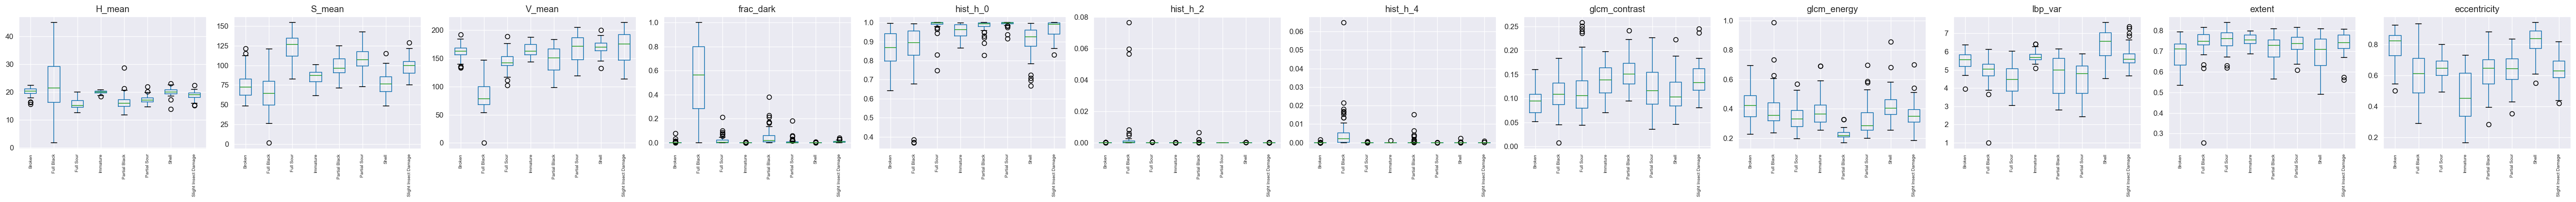

In [34]:
promissoras = [
    'H_mean', 'S_mean', 'V_mean', 'frac_dark',
    'hist_h_0', 'hist_h_2', 'hist_h_4',
    'glcm_contrast', 'glcm_energy',
    'lbp_var', 'extent', 'eccentricity'
]

fig, axes = plt.subplots(1, len(promissoras), figsize=(4*len(promissoras), 4))
for i, f in enumerate(promissoras):
    df.boxplot(column=f, by='rotulo', ax=axes[i])
    axes[i].set_title(f)
    axes[i].set_xlabel('')
    plt.setp(axes[i].get_xticklabels(), rotation=90, fontsize=6)
plt.suptitle('')
plt.tight_layout()
plt.savefig('../outputs/gráficos de features/boxplots_features.png')
plt.show()

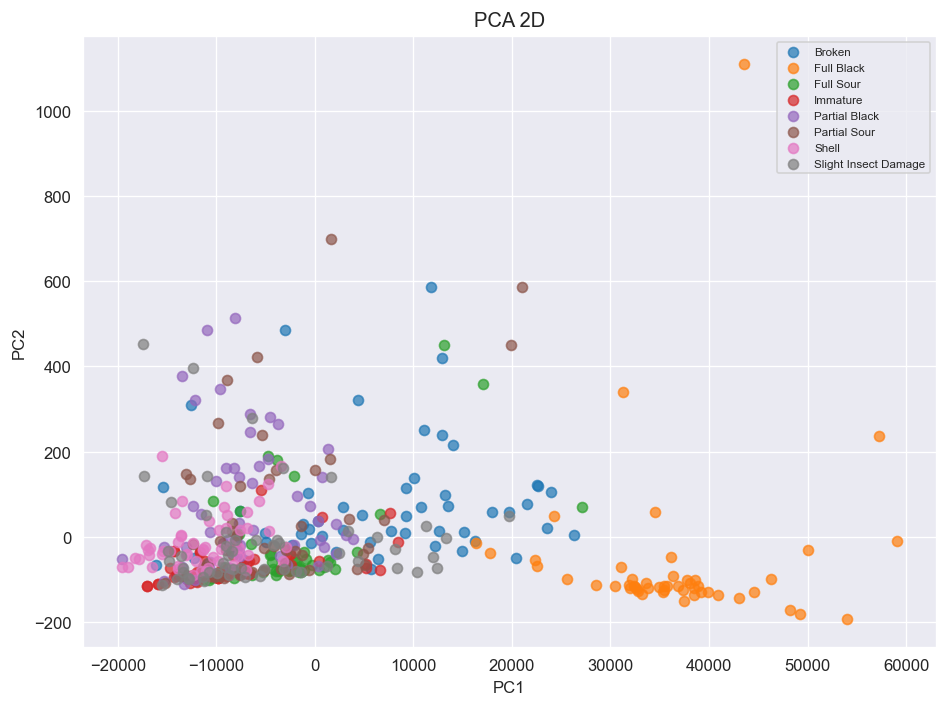

In [35]:
X = df.drop(columns=['rotulo','caminho']).values
X = np.nan_to_num(X)
y = df['rotulo'].values

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for rotulo in np.unique(y):
    sel = y == rotulo
    plt.scatter(Z[sel,0], Z[sel,1], label=rotulo, alpha=0.7)
plt.legend(fontsize=7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D')
plt.tight_layout()
plt.savefig('../outputs/gráficos de features/pca_2d.png')
plt.show()

SelectKBest top 10: ['S_mean', 'V_mean', 'frac_dark', 'hist_h_6', 'hist_h_7', 'area', 'eccentricity', 'perimeter', 'hu_2', 'lbp_var']


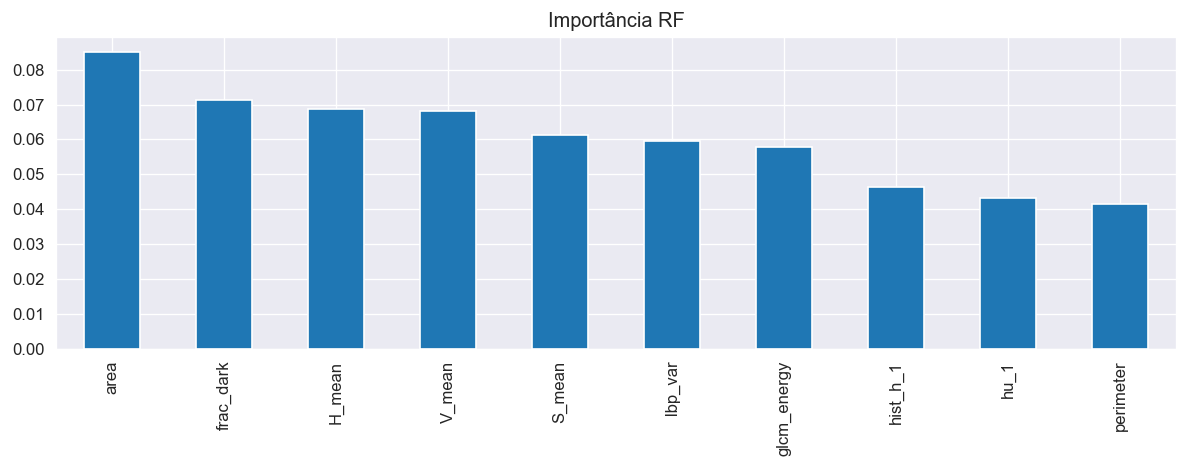

Features consenso: ['S_mean', 'V_mean', 'frac_dark', 'hist_h_6', 'hist_h_7', 'area', 'eccentricity', 'perimeter', 'hu_2', 'lbp_var', 'H_mean', 'glcm_energy', 'hist_h_1', 'hu_1', 'hu_3', 'glcm_correlation']


In [43]:
feature_cols = [c for c in df.columns if c not in ('rotulo','caminho')]
X = df[feature_cols].values
X = np.nan_to_num(X)
mapping = {c:i for i,c in enumerate(df['rotulo'].unique())}
y_enc = df['rotulo'].map(mapping).values

# SelectKBest
skb = SelectKBest(f_classif, k=10)
skb.fit(X, y_enc)
top_k = [f for f, s in zip(feature_cols, skb.get_support()) if s]
print('SelectKBest top 10:', top_k)

# Importância RF
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y_enc)
imp_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
imp_rf.head(10).plot(kind='bar', figsize=(10,4), title='Importância RF')
plt.tight_layout()
plt.savefig('../outputs/tabela de métricas/importancia_rf.png')
plt.show()

# Coeficientes LogReg
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10000, solver='saga', random_state=42))
])
lr_pipe.fit(X, y_enc)
coefs = np.mean(np.abs(lr_pipe.named_steps['lr'].coef_), axis=0)
imp_lr = pd.Series(coefs, index=feature_cols).sort_values(ascending=False)
imp_lr.head(10).to_csv('../outputs/figuras/coef_logreg.csv')

# Consenso
consenso = list(dict.fromkeys(top_k + list(imp_rf.head(10).index) + list(imp_lr.head(10).index)))


In [44]:
stats_por_classe = df.groupby('rotulo')[promissoras].agg(['mean', 'median']).round(3)
print(stats_por_classe)

                      H_mean           S_mean            V_mean           \
                        mean  median     mean   median     mean   median   
rotulo                                                                     
Broken                20.116  20.339   75.619   72.480  161.779  162.570   
Full Black            23.313  21.407   65.366   64.648   83.749   78.788   
Full Sour             15.680  15.204  124.340  126.637  145.535  142.037   
Immature              19.918  19.956   85.495   87.201  165.019  163.178   
Partial Black         16.207  15.887   98.561   96.411  149.045  151.132   
Partial Sour          17.178  17.064  107.669  107.039  168.213  171.855   
Shell                 20.065  20.059   76.276   76.456  171.259  170.183   
Slight Insect Damage  18.806  18.988   99.098   99.636  170.947  175.650   

                     frac_dark        hist_h_0         ... glcm_contrast  \
                          mean median     mean median  ...          mean   
rotulo     